# Customer Churn Supervised Machine Learning Predictive Model

## Problem Statement:Create a predictive model that can predict whether customers are at risk of leaving or not. 

In [1]:
import pandas as pd 
import numpy as np
CustomerChurnData=pd.read_csv("C:/Users/Ankit Raut/Python IVY Feb-2024 (2)/Python IVY Feb-2024/My ML Projects/Classification Projects/Customer Churn Prediction/Customer-Churn-Prediction.csv",
encoding='latin-1')
print('Before deleting rows:',CustomerChurnData.shape)
CustomerChurnData.drop_duplicates(inplace=True) 
print('After deleting rows:',CustomerChurnData.shape) 
CustomerChurnData.head() 

Before deleting rows: (7043, 21)
After deleting rows: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
CustomerChurnData.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [3]:
CustomerChurnData['TotalCharges'] = pd.to_numeric(
    CustomerChurnData['TotalCharges'],
    errors='coerce'
)

In [4]:
CustomerChurnData.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6530
Churn                  2
dtype: int64

In [5]:
CustomerChurnData['tenure']=pd.to_numeric(CustomerChurnData['tenure'],errors='coerce')

In [6]:
CustomerChurnData.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)

## Target Variable is Churn

<Axes: xlabel='Churn'>

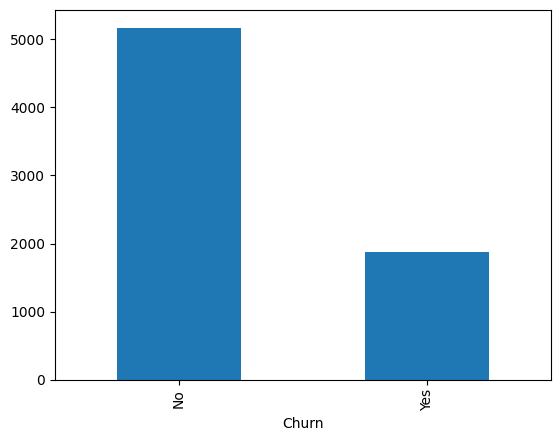

In [8]:
CustomerChurnData.groupby(['Churn']).size().plot(kind='bar')

In [9]:
CustomerChurnData.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6530
Churn                  2
dtype: int64

In [10]:
CustomerChurnData.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

## CategoricalColumns:['gender', 'SeniorCitizen', 'Partner', 'Dependents','PhoneService', 'MultipleLines', 'InternetService',
## 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
## 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
## 'PaymentMethod']
## ContinousColumns:['tenure','MonthlyCharges', 'TotalCharges'] 

In [11]:
CustomerChurnData.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [12]:
CustomerChurnData.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7032.000000,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,NaN,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2809,2785,3875,4171,2365,NaN,NaN,5174
mean,NaN,NaN,0.162289,NaN,NaN,32.370865,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,2283.300441,NaN
std,NaN,NaN,0.368742,NaN,NaN,24.559231,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,2266.771362,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,18.800000,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,401.450000,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,1397.475000,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,3794.737500,NaN


In [13]:
CustomerChurnData.drop('customerID',axis=1,inplace=True)

In [14]:
CustomerChurnData.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Visual Exploratory Data Analysis

## Bar Plots

In [15]:
CustomerChurnData['PaperlessBilling'].unique()

<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

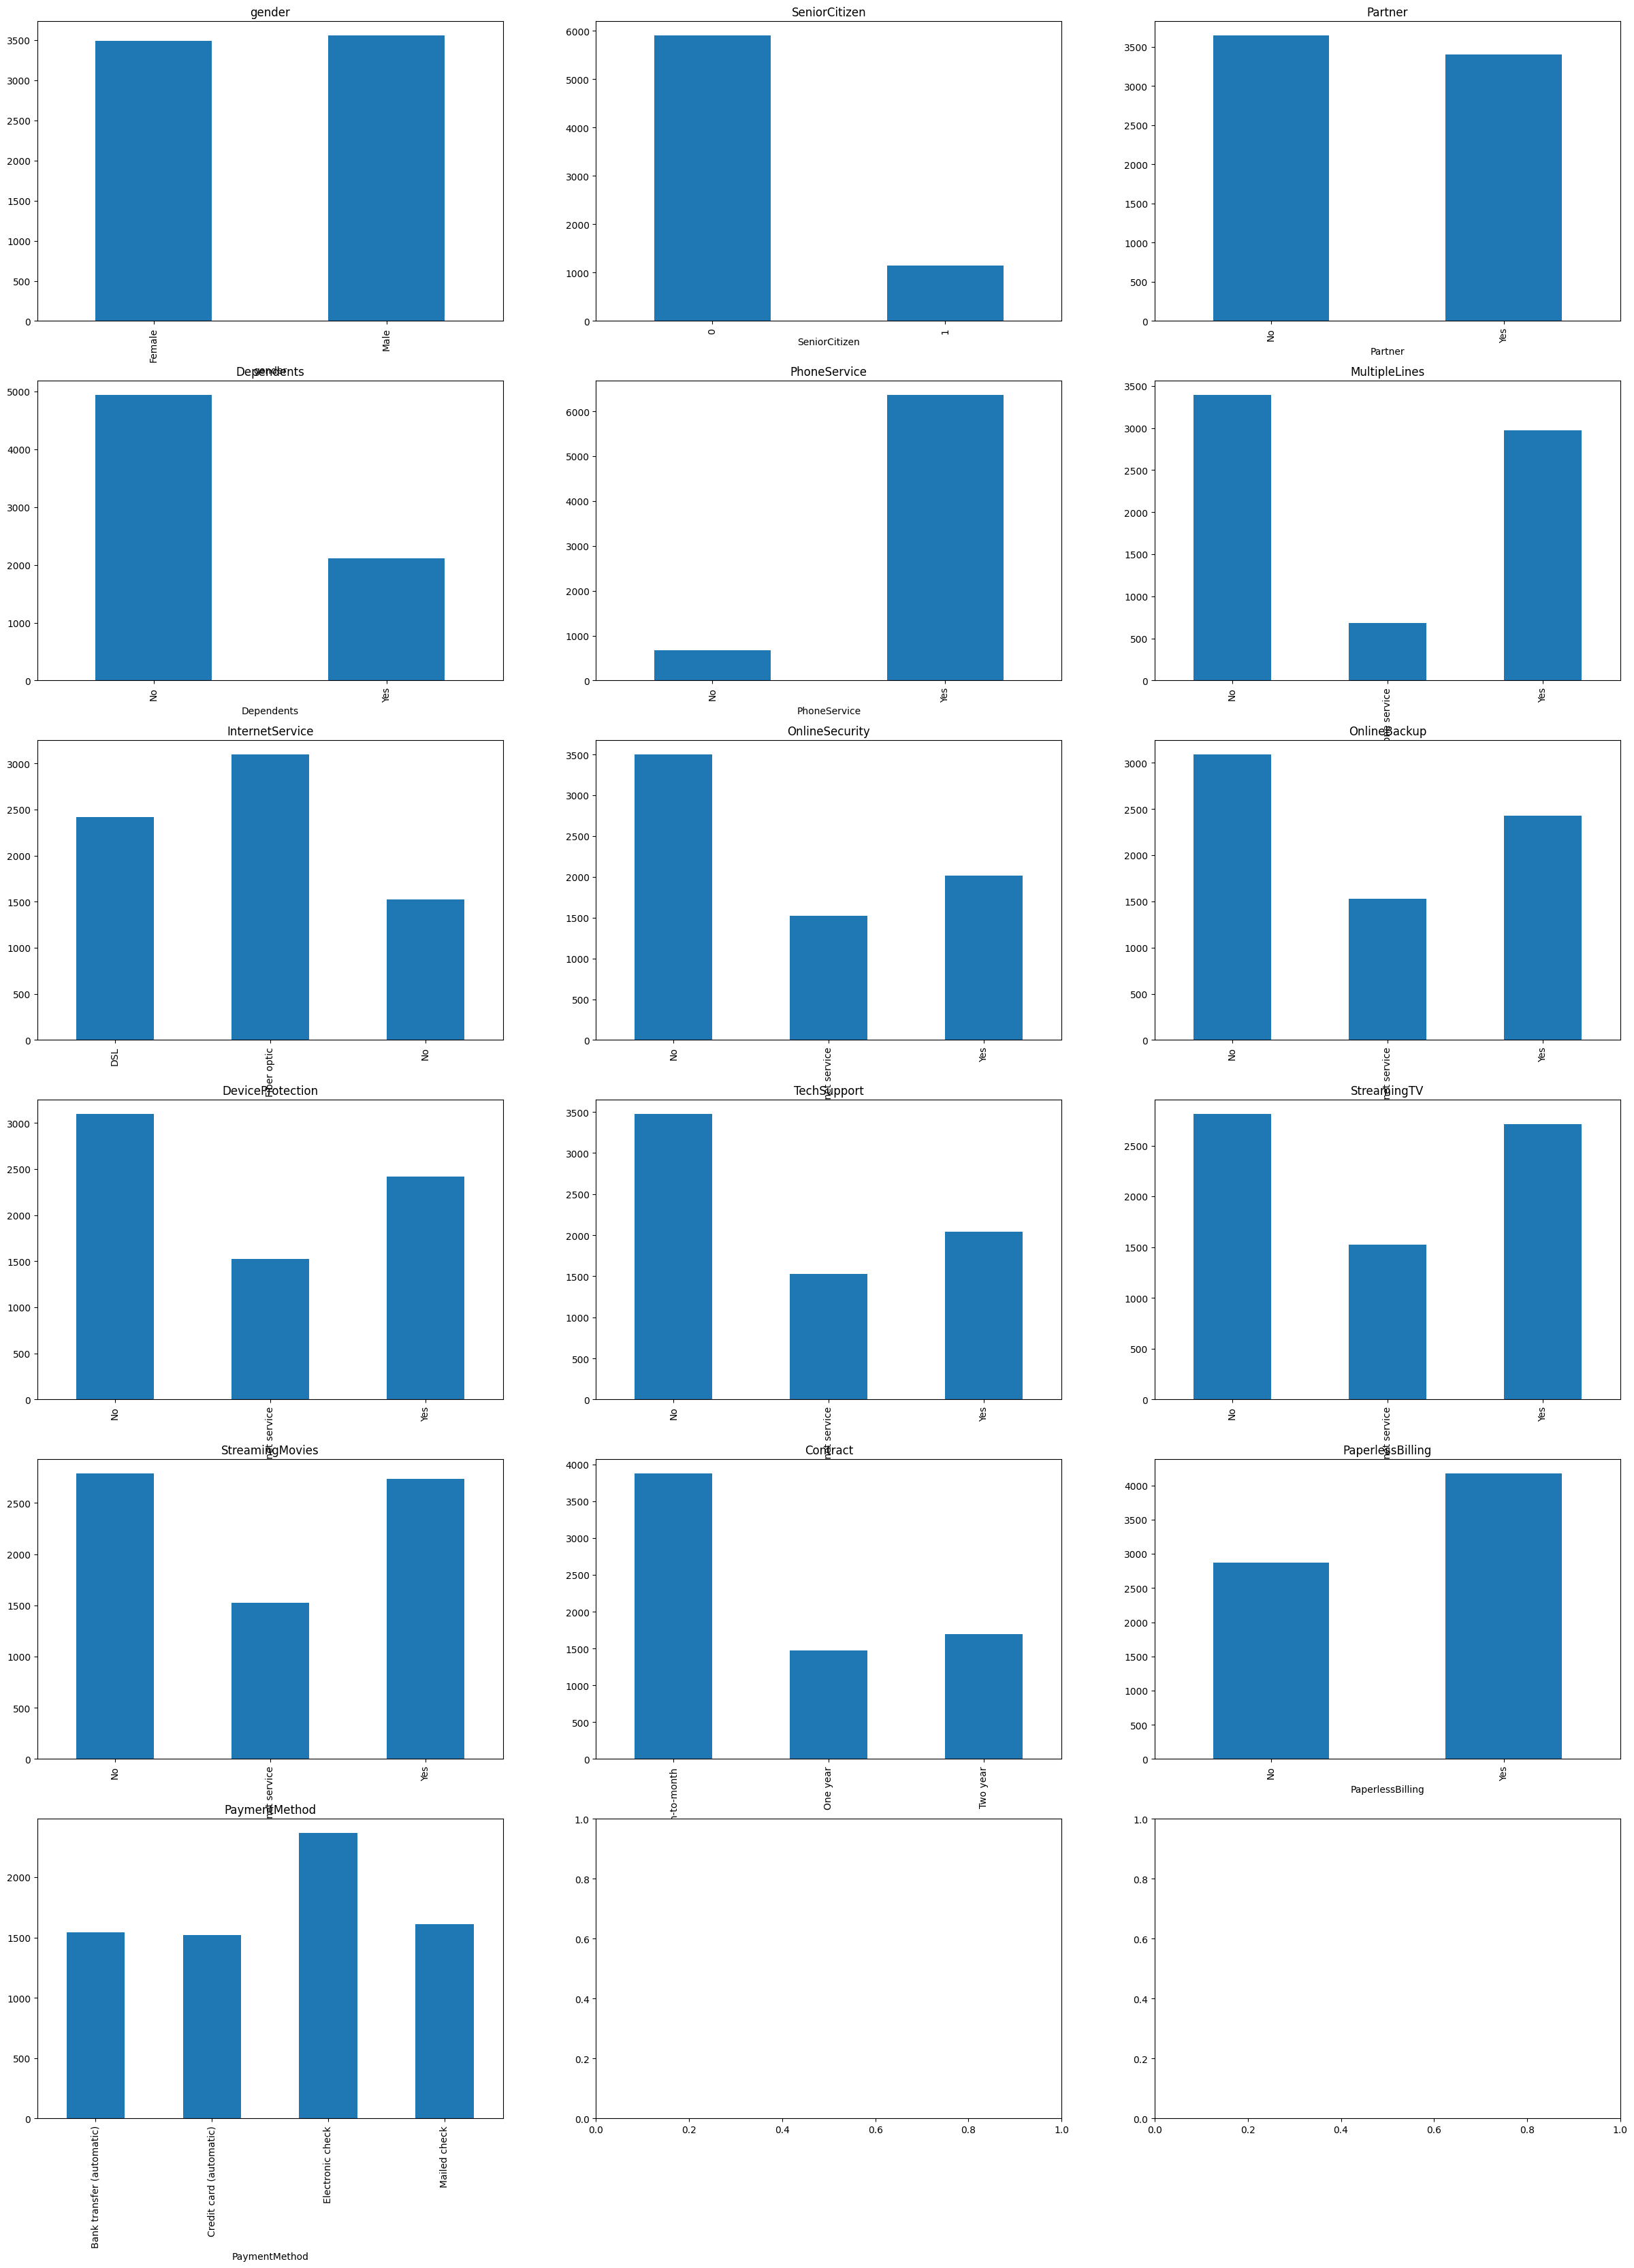

In [16]:
CategoricalColumns=['gender', 'SeniorCitizen', 'Partner', 'Dependents','PhoneService', 'MultipleLines', 'InternetService',
'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
'PaymentMethod'] 
import matplotlib.pyplot as plt
fig, subplots=plt.subplots(6,3,figsize=(30,40)) 
subplots=subplots.flatten()
for cols,no_of_cols in zip(CategoricalColumns,range(len(CategoricalColumns))):
    CustomerChurnData.groupby(cols).size().plot(kind='bar',ax=subplots[no_of_cols],title=(cols))

## Histogram

<Axes: >

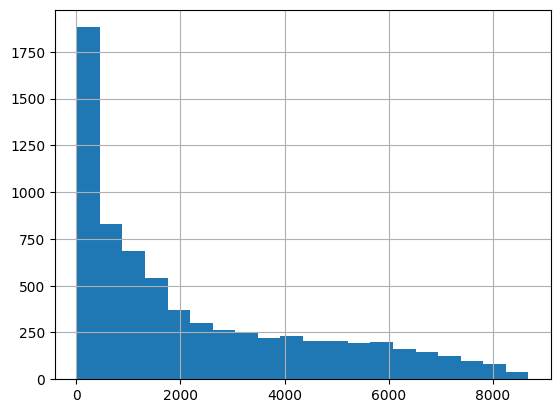

In [17]:
CustomerChurnData['TotalCharges'].hist(bins=20)

In [18]:
CustomerChurnData['TotalCharges'].describe()

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64

array([[<Axes: title={'center': 'tenure'}>,
        <Axes: title={'center': 'MonthlyCharges'}>],
       [<Axes: title={'center': 'TotalCharges'}>, <Axes: >]], dtype=object)

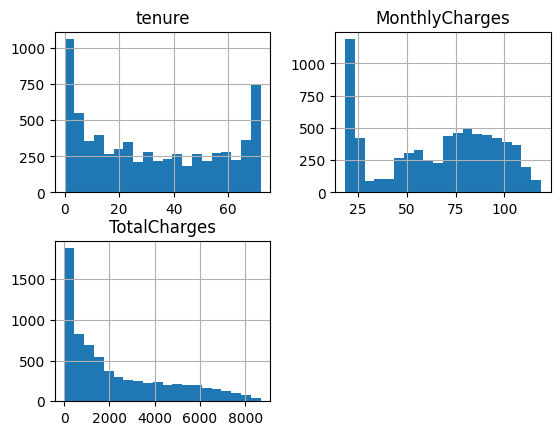

In [19]:
CustomerChurnData[['tenure','MonthlyCharges', 'TotalCharges']].hist(bins=20)

## Outlier Treatment is not needed.

## Missing Value Treatment

In [21]:
CustomerChurnData['TotalCharges']=pd.to_numeric(CustomerChurnData['TotalCharges'],errors='coerce')
CustomerChurnData['tenure']=pd.to_numeric(CustomerChurnData['tenure'],errors='coerce') 

## try changing values of mean and median for better accuracy of the model

In [22]:
print(CustomerChurnData['TotalCharges'].median())
print(CustomerChurnData['TotalCharges'].mean())
CustomerChurnData['TotalCharges'].describe() 

1397.475
2283.3004408418656


count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64

In [23]:
CustomerChurnData.loc[CustomerChurnData['TotalCharges'].isnull(),'TotalCharges'] =1397.475000

## Imbalance Treatment is not needed.

## Categorical Vs Continuous -- Box Plots

In [ ]:
CustomerChurnData.columns

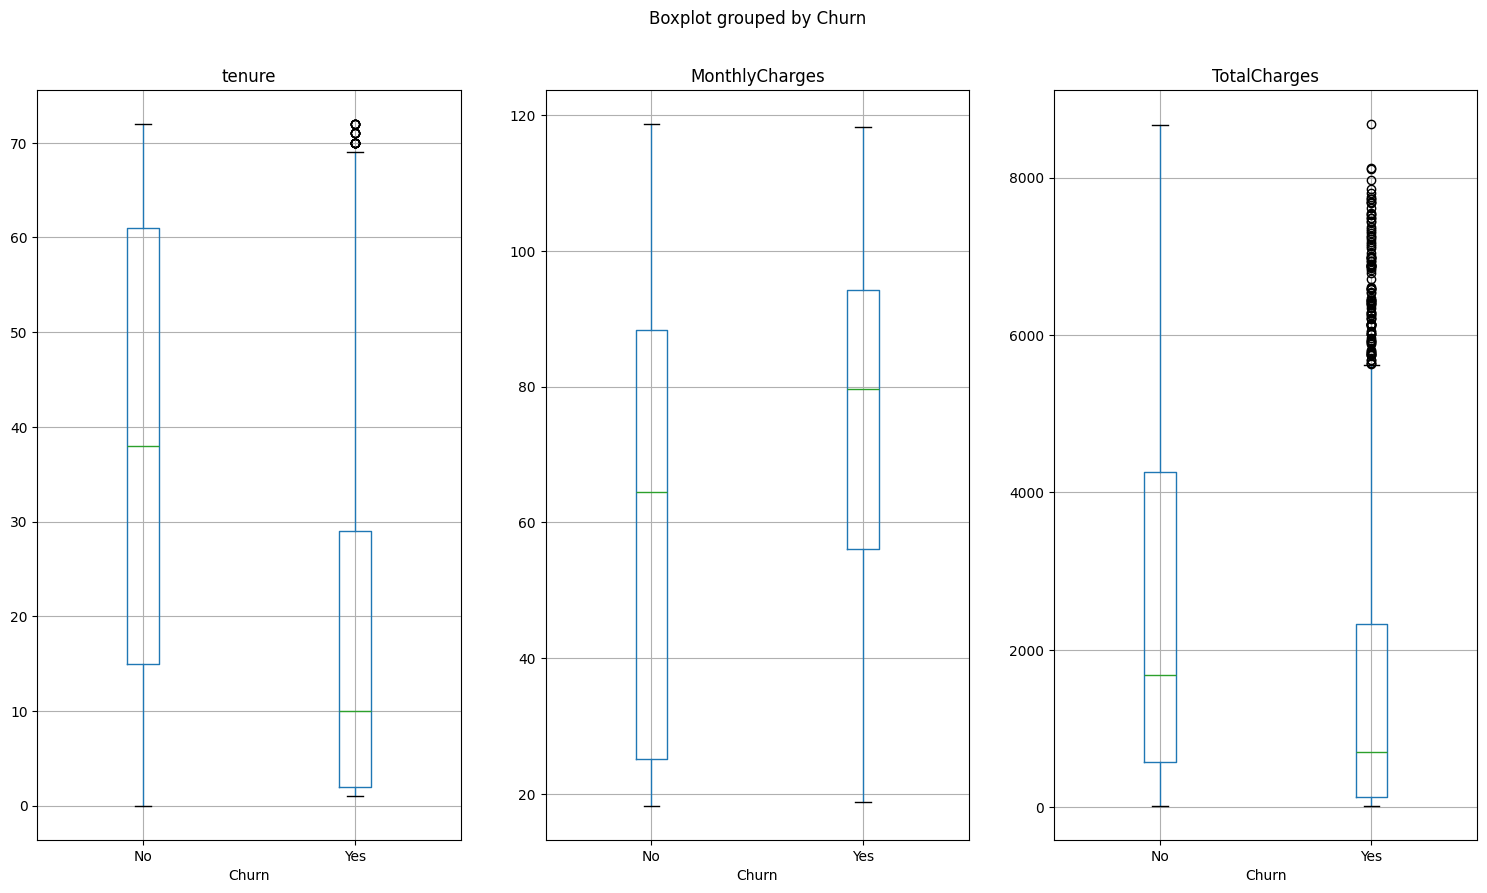

In [24]:
ContinousColumns=['tenure','MonthlyCharges', 'TotalCharges']
import matplotlib.pyplot as plt 
fig, subplots=plt.subplots(1,3,figsize=(18,10))
subplots=subplots.flatten()
for cols,no_of_cols in zip(ContinousColumns,range(len(ContinousColumns))):
    CustomerChurnData.boxplot(column=cols,by='Churn',vert=True,ax=subplots[no_of_cols]) 

## Statistical Feature Selection (Categorical Vs Continuous) using ANOVA test

In [25]:
ContinousColumns=['tenure','MonthlyCharges', 'TotalCharges']
def functionAnova(inpData,targetVariable,ContinousColumns):
    from scipy.stats import f_oneway
    SelectedPredictors=[]
    for cols in ContinousColumns:
        CategoricalGroupLists=inpData.groupby(targetVariable)[cols].apply(list)
        AnovaResults=f_oneway(*CategoricalGroupLists)
        if AnovaResults[1]<0.05:
            print(cols,'is correlated with ',targetVariable,' and p value is:',AnovaResults[1])
            SelectedPredictors.append(cols)
        else:
            print(cols,'is not correlated with ',targetVariable,' and p value is:',AnovaResults[1])
    return SelectedPredictors
functionAnova(inpData=CustomerChurnData,targetVariable='Churn',ContinousColumns=['tenure','MonthlyCharges', 'TotalCharges'])

tenure is correlated with  Churn  and p value is: 7.4979258651022415e-205
MonthlyCharges is correlated with  Churn  and p value is: 2.7066456068950115e-60
TotalCharges is correlated with  Churn  and p value is: 7.508609056724576e-64


['tenure', 'MonthlyCharges', 'TotalCharges']

## Relationship exploration: Categorical Vs Categorical -- Grouped Bar Charts

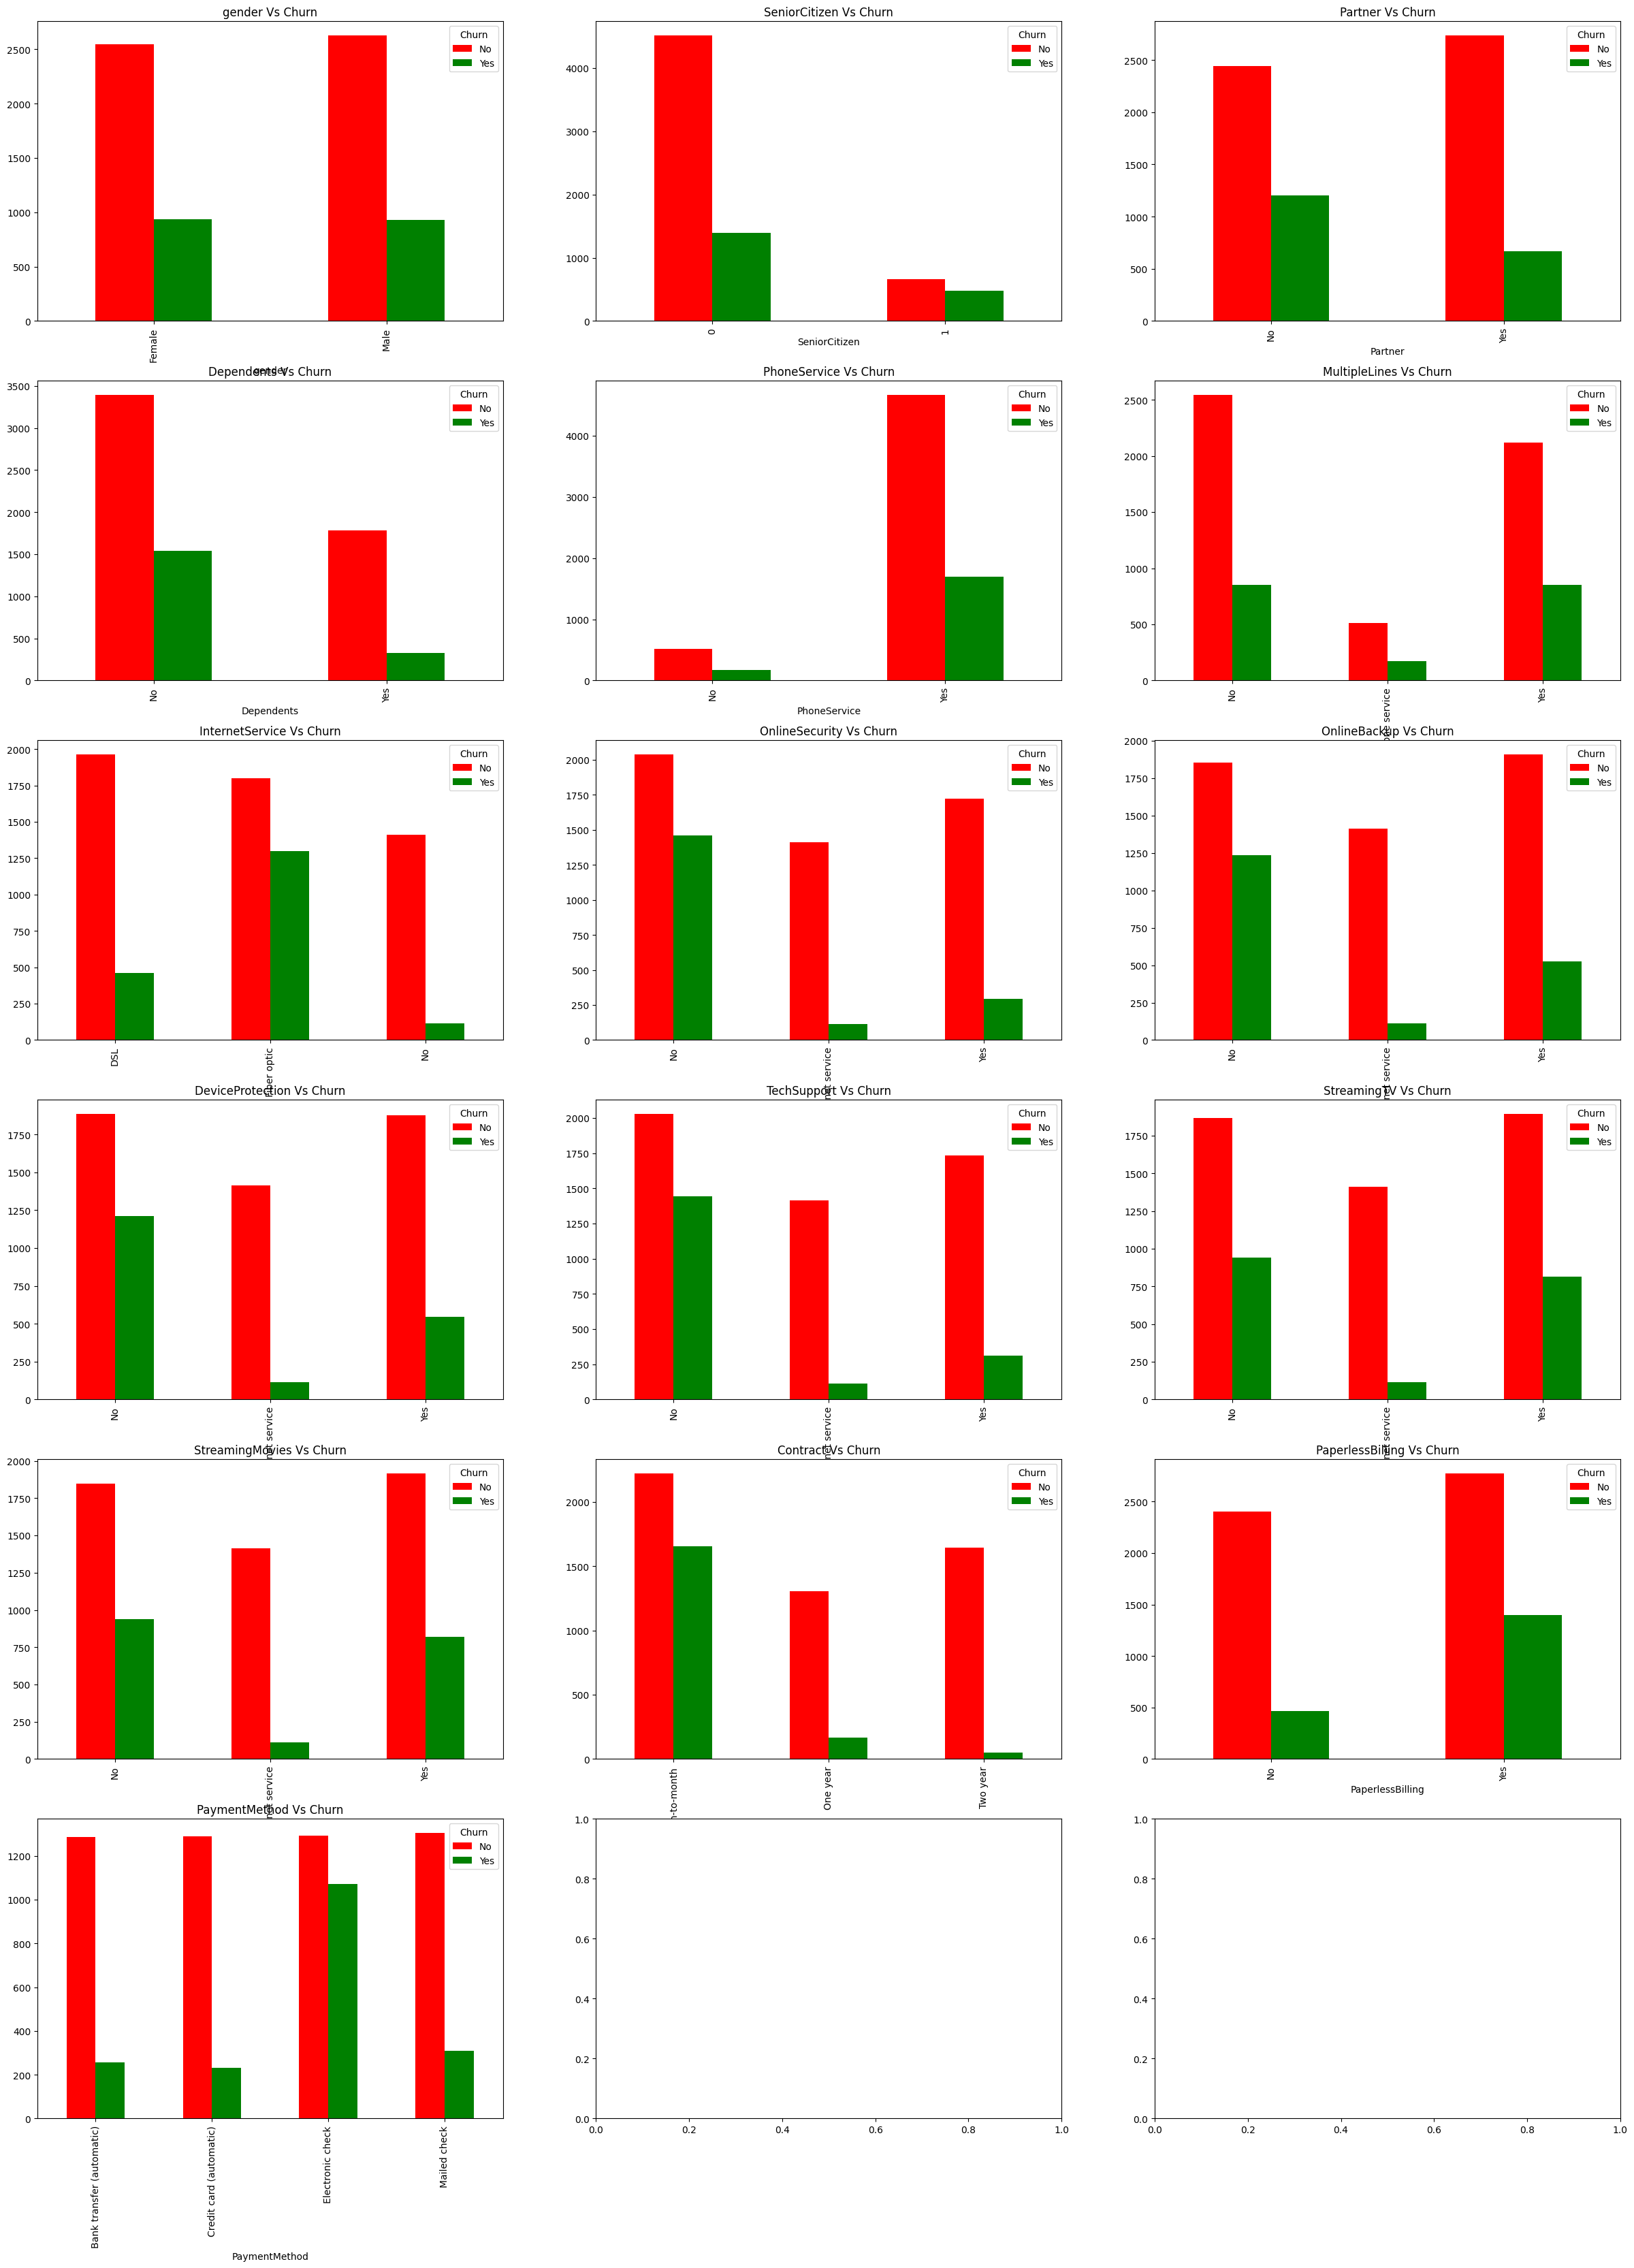

In [26]:
CategoricalColumns=['gender', 'SeniorCitizen', 'Partner', 'Dependents','PhoneService', 'MultipleLines', 'InternetService',
'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
'PaymentMethod']
import matplotlib.pyplot as plt
fig,subplots=plt.subplots(6,3,figsize=(30,40))
subplots=subplots.flatten() 
for cols,no_of_cols in zip(CategoricalColumns,range(len(CategoricalColumns))):
    crosstabresults=pd.crosstab(columns=CustomerChurnData['Churn'],index=CustomerChurnData[cols])
    crosstabresults.plot.bar(color=['red','green'],ax=subplots[no_of_cols],title=cols+' Vs '+'Churn') 

In [27]:
CategoricalColumns=['gender', 'SeniorCitizen', 'Partner', 'Dependents','PhoneService', 'MultipleLines', 'InternetService',
'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport','StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling','PaymentMethod']
def chi2_contingency(inpData,targetVariable,CategoricalColumns):
    from scipy.stats import chi2_contingency
    SelectedPredictors=[]
    for cols in CategoricalColumns:
        CrossTabResult=pd.crosstab(columns=inpData['Churn'],index=inpData[cols])
        ChiSqResult=chi2_contingency(CrossTabResult) 
        if ChiSqResult[1]<0.05:
            print(cols,' is correlated with Churn and P value is: ',ChiSqResult[1])
            SelectedPredictors.append(cols)
        else:
            print(cols,' is not correlated with Churn and P value is: ',ChiSqResult[1])
    return SelectedPredictors
chi2_contingency(CustomerChurnData,'Churn',CategoricalColumns)

gender  is not correlated with Churn and P value is:  0.48657873605618596
SeniorCitizen  is correlated with Churn and P value is:  8.060729392249123e-37
Partner  is correlated with Churn and P value is:  2.1399113440759935e-36
Dependents  is correlated with Churn and P value is:  4.9249216612154196e-43
PhoneService  is not correlated with Churn and P value is:  0.3387825358066928
MultipleLines  is correlated with Churn and P value is:  0.0034643829548773003
InternetService  is correlated with Churn and P value is:  9.571788222840544e-160
OnlineSecurity  is correlated with Churn and P value is:  2.661149635176552e-185
OnlineBackup  is correlated with Churn and P value is:  2.0797592160864276e-131
DeviceProtection  is correlated with Churn and P value is:  5.505219496457244e-122
TechSupport  is correlated with Churn and P value is:  1.4430840279998987e-180
StreamingTV  is correlated with Churn and P value is:  6.233521926776746e-82
StreamingMovies  is correlated with Churn and P value is

['SeniorCitizen',
 'Partner',
 'Dependents',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

## Two columns are not selected from above

In [28]:
SelectedColumns=['gender','PhoneService','SeniorCitizen',
 'Partner',
 'Dependents',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling', 
 'PaymentMethod','tenure', 'MonthlyCharges', 'TotalCharges'] 
DataForMLCustomerChurnData=CustomerChurnData[SelectedColumns]
DataForMLCustomerChurnData.to_pickle('DataForMLCustomerChurnData.pkl')
DataForMLCustomerChurnData=pd.read_pickle('DataForMLCustomerChurnData.pkl') 
DataForMLCustomerChurnData_Numeric=pd.get_dummies(DataForMLCustomerChurnData)

DataForMLCustomerChurnData_Numeric.replace({True:1,False:0},inplace=True) 
DataForMLCustomerChurnData_Numeric.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,PhoneService_No,PhoneService_Yes,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,1,0,1,0,0,1,1,0,0,1,0,1,0,0,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0
1,0,34,56.95,1889.50,0,1,0,1,1,0,1,0,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0,0,1
2,0,2,53.85,108.15,0,1,0,1,1,0,1,0,1,0,0,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,1
3,0,45,42.30,1840.75,0,1,1,0,1,0,1,0,0,1,0,1,0,0,0,0,1,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,0,1,0,1,0,1,0,0,0
4,0,2,70.70,151.65,1,0,0,1,1,0,1,0,1,0,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0


In [33]:
DataForMLCustomerChurnData_Numeric.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Female', 'gender_Male', 'PhoneService_No', 'PhoneService_Yes',
       'Partner_No', 'Partner_Yes', 'Dependents_No', 'Dependents_Yes',
       'MultipleLines_No', 'MultipleLines_No phone service',
       'MultipleLines_Yes', 'InternetService_DSL',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes', 'OnlineBackup_No',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No', 'DeviceProtection_No internet service',
       'DeviceProtection_Yes', 'TechSupport_No',
       'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No', 'StreamingMovies_No internet service',
       'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', '

In [29]:
DataForMLCustomerChurnData_Numeric=DataForMLCustomerChurnData_Numeric.drop([ 'tenure', 'MonthlyCharges', 'TotalCharges'],axis=1) 

In [30]:
DataForMLCustomerChurnData_Numeric=DataForMLCustomerChurnData_Numeric.astype(int)

In [31]:
DataForMLCustomerChurnData_Numeric.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 42 columns):
 #   Column                                   Non-Null Count  Dtype
---  ------                                   --------------  -----
 0   SeniorCitizen                            7043 non-null   int64
 1   gender_Female                            7043 non-null   int64
 2   gender_Male                              7043 non-null   int64
 3   PhoneService_No                          7043 non-null   int64
 4   PhoneService_Yes                         7043 non-null   int64
 5   Partner_No                               7043 non-null   int64
 6   Partner_Yes                              7043 non-null   int64
 7   Dependents_No                            7043 non-null   int64
 8   Dependents_Yes                           7043 non-null   int64
 9   MultipleLines_No                         7043 non-null   int64
 10  MultipleLines_No phone service           7043 non-null   int64
 11  MultipleLines_Y

In [32]:
DataForMLCustomerChurnData_Numeric[['tenure', 'MonthlyCharges', 'TotalCharges']]=CustomerChurnData[['tenure', 'MonthlyCharges', 'TotalCharges']]

In [33]:
DataForMLCustomerChurnData_Numeric.head()

,SeniorCitizen,gender_Female,gender_Male,PhoneService_No,PhoneService_Yes,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure,MonthlyCharges,TotalCharges
0,0,1,0,1,0,0,1,1,0,0,1,0,1,0,0,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0,1,29.85,29.85
1,0,0,1,0,1,1,0,1,0,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0,0,1,34,56.95,1889.50
2,0,0,1,0,1,1,0,1,0,1,0,0,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,1,2,53.85,108.15
3,0,0,1,1,0,1,0,1,0,0,1,0,1,0,0,0,0,1,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,0,1,0,1,0,1,0,0,0,45,42.30,1840.75
4,0,1,0,0,1,1,0,1,0,1,0,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0,2,70.70,151.65


In [34]:
CustomerChurnData['Churn']=CustomerChurnData['Churn'].replace({'Yes':1,'No':0},inplace=True)
CustomerChurnData['Churn'] = CustomerChurnData['Churn'].astype(int) 
DataForMLCustomerChurnData_Numeric['Churn'] = CustomerChurnData['Churn']

C:\Users\Ankit Raut\AppData\Local\Temp\ipykernel_90484\1216205154.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  CustomerChurnData['Churn']=CustomerChurnData['Churn'].replace({'Yes':1,'No':0},inplace=True)


In [35]:
DataForMLCustomerChurnData_Numeric.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 46 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   SeniorCitizen                            7043 non-null   int64  
 1   gender_Female                            7043 non-null   int64  
 2   gender_Male                              7043 non-null   int64  
 3   PhoneService_No                          7043 non-null   int64  
 4   PhoneService_Yes                         7043 non-null   int64  
 5   Partner_No                               7043 non-null   int64  
 6   Partner_Yes                              7043 non-null   int64  
 7   Dependents_No                            7043 non-null   int64  
 8   Dependents_Yes                           7043 non-null   int64  
 9   MultipleLines_No                         7043 non-null   int64  
 10  MultipleLines_No phone service           7043 non-null   in

In [44]:
DataForMLCustomerChurnData_Numeric.shape

(7043, 46)

In [36]:
targetVariable='Churn'
predictors=['SeniorCitizen', 'gender_Female', 'gender_Male', 'PhoneService_No',
       'PhoneService_Yes', 'Partner_No', 'Partner_Yes', 'Dependents_No',
       'Dependents_Yes', 'MultipleLines_No', 'MultipleLines_No phone service',
       'MultipleLines_Yes', 'InternetService_DSL',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes', 'OnlineBackup_No',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No', 'DeviceProtection_No internet service',
       'DeviceProtection_Yes', 'TechSupport_No',
       'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No', 'StreamingMovies_No internet service',
       'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'PaperlessBilling_No', 'PaperlessBilling_Yes',
       'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'tenure', 'MonthlyCharges', 'TotalCharges']
predictors=[ 'Contract_Month-to-month', 
       'tenure', 'MonthlyCharges', 'TotalCharges']
X=DataForMLCustomerChurnData_Numeric[predictors].values
y=DataForMLCustomerChurnData_Numeric[targetVariable].values
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=12,test_size=0.2)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape) 

(5634, 4)
(5634,)
(1409, 4)
(1409,)


In [37]:
X_train[0:5]

array([[0.00000e+00, 5.70000e+01, 2.01000e+01, 1.08770e+03],
       [0.00000e+00, 7.00000e+01, 1.16550e+02, 8.15230e+03],
       [1.00000e+00, 4.70000e+01, 8.72000e+01, 4.01745e+03],
       [0.00000e+00, 2.30000e+01, 2.01500e+01, 4.05600e+02],
       [1.00000e+00, 1.60000e+01, 7.44500e+01, 1.26135e+03]])

In [38]:
y_train[0:10]

array([0, 0, 0, 0, 0, 0, 0, 1, 1, 0])

In [39]:
from sklearn.linear_model import LogisticRegression
clf=LogisticRegression(C=5,penalty='l2',solver='newton-cg')
LOG=clf.fit(X_train,y_train)
prediction=LOG.predict(X_test)
from sklearn import metrics
print(metrics.classification_report(y_test,prediction))
print(metrics.confusion_matrix(y_test,prediction))
F1_Score=metrics.f1_score(y_test,prediction,average='weighted')
print('Sample Accuracy of Model:',round((np.mean(F1_Score)),2)*100,'%')
from sklearn.model_selection import cross_val_score
Accuracy_Value=cross_val_score(LOG,X,y,cv=5,scoring='f1_weighted')
print(Accuracy_Value)
print('Final Accuracy of the Model:',round(np.mean(Accuracy_Value),2)*100,'%')

              precision    recall  f1-score   support

           0       0.82      0.89      0.85      1043
           1       0.59      0.46      0.51       366

    accuracy                           0.78      1409
   macro avg       0.71      0.67      0.68      1409
weighted avg       0.76      0.78      0.77      1409

[[926 117]
 [199 167]]
Sample Accuracy of Model: 77.0 %
[0.78190188 0.78446037 0.76506202 0.78379724 0.77984348]
Final Accuracy of the Model: 78.0 %


              precision    recall  f1-score   support

           0       0.83      0.88      0.85      1043
           1       0.57      0.48      0.52       366

    accuracy                           0.77      1409
   macro avg       0.70      0.68      0.68      1409
weighted avg       0.76      0.77      0.76      1409

[[913 130]
 [192 174]]
Sample Accuracy of Model: 76.0 %
[0.78190188 0.78446037 0.76506202 0.78379724 0.77984348]
Final Accuracy of the Model: 78.0 %


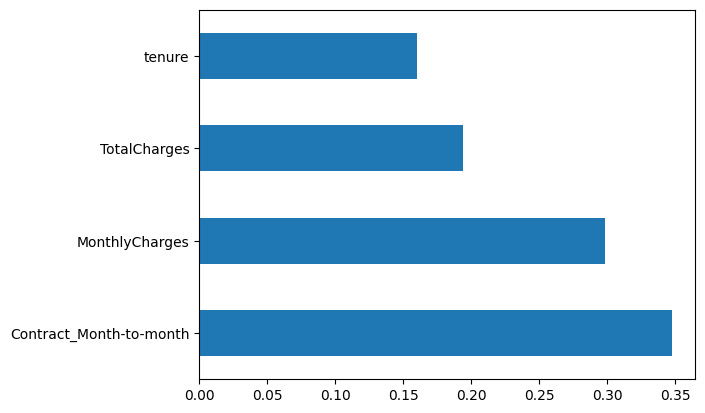

In [40]:
from sklearn import tree
clf=tree.DecisionTreeClassifier(max_depth=10,criterion='entropy') 
DTree=clf.fit(X_train,y_train)
prediction=DTree.predict(X_test)

feature_importances=pd.Series(DTree.feature_importances_,index=predictors)
feature_importances.nlargest(10).plot(kind='barh')
from sklearn import metrics
print(metrics.classification_report(y_test,prediction))
print(metrics.confusion_matrix(y_test,prediction))
F1_Score=metrics.f1_score(y_test,prediction,average='weighted')
print('Sample Accuracy of Model:',round((np.mean(F1_Score)),2)*100,'%')
from sklearn.model_selection import cross_val_score
Accuracy_Values=cross_val_score(DTree,X,y,cv=5,scoring='f1_weighted')
print(Accuracy_Value)
print('Final Accuracy of the Model:',round(np.mean(Accuracy_Value),2)*100,'%')

In [105]:
# Creating some new data rows
NewData=pd.DataFrame(data=[[0,45,725,4556],
                           [1,67,833,4434],
                           [1,67,121,7878]], columns=predictors)
NewData

,Contract_Month-to-month,tenure,MonthlyCharges,TotalCharges
0,0,45,725,4556
1,1,67,833,4434
2,1,67,121,7878


In [106]:
new_X=NewData.values
new_X

array([[   0,   45,  725, 4556],
       [   1,   67,  833, 4434],
       [   1,   67,  121, 7878]])

In [107]:
DTree.predict(new_X)

array([0, 1, 0])

In [108]:
def GenerateSurvialPred(inpData):
    new_X=inpData.values
    pred=DTree.predict(new_X)
    inpData['Prediction']=pred
    return(inpData)
GenerateSurvialPred(NewData)

,Contract_Month-to-month,tenure,MonthlyCharges,TotalCharges,Prediction
0,0,45,725,4556,0
1,1,67,833,4434,1
2,1,67,121,7878,0


## Refer:https://www.kaggle.com/datasets/ranasarkar15/customerchurndatasets